<a href="https://colab.research.google.com/github/VarunDotpy/GithubDay1/blob/main/Extraction_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this task, you will extract text and bounding boxes from a real-world Loan Worksheet PDF using PyMuPDF, focusing specifically on capturing the document's text along with its spatial layout.

1. Setup environment
2. explore the document
3. extract the data with bbox
4. store in sturctured format - JSON
5. print image with bbox rectangle (Extra step)

In [ ]:
#1. setup environment

!pip install PyMuPDF

#upload the document in colab instance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 66.2 MB/s eta 0:00:00


In [ ]:
#explore the document data


import fitz #to find out bbox coords & extract data

sheet = fitz.open("LenderFeesWorksheetNew.pdf")
print('total pages is ', len(sheet))
sheet.metadata #to get the metadata


total pages is  1


{'format': 'PDF 1.3',
 'title': 'POINT Document',
 'author': '',
 'subject': '',
 'keywords': '',
 'creator': '',
 'producer': 'Amyuni PDF Converter version 4.5.2.3',
 'creationDate': "D:20151001155359-07'00'",
 'modDate': '',
 'trapped': '',
 'encryption': None}

In [ ]:

import json


page1 = sheet[0] #the first page only since only one page
textlist = []
coordlist = []
output = []
#extract the text with bbox
text = page1.get_text('words') #with bbox coords
for word in text:
  x0,y0,x1,y1,words, block_no, line_no, word_no  = word
  bbox_coord = x0,y0,x1,y1
  #print(f'word is {words} and coordinate is {x0,y0,x1,y1}')
  textlist.append(words)
  coordlist.append(bbox_coord)
  current_word_data = {'text': words, 'bbox': bbox_coord}
  output.append(current_word_data) #create a JSON structure
print(output) #the JSON data that we will dump into a JSON


[{'text': 'Your', 'bbox': (36.0, 26.097490310668945, 60.943878173828125, 38.3197021484375)}, {'text': 'actual', 'bbox': (63.95075607299805, 26.097490310668945, 95.60314178466797, 38.3197021484375)}, {'text': 'rate,', 'bbox': (98.61001586914062, 26.097490310668945, 121.74352264404297, 38.3197021484375)}, {'text': 'payment,', 'bbox': (124.75039672851562, 26.097490310668945, 172.82777404785156, 38.3197021484375)}, {'text': 'and', 'bbox': (175.8346710205078, 26.097490310668945, 195.30154418945312, 38.3197021484375)}, {'text': 'cost', 'bbox': (198.3084259033203, 26.097490310668945, 220.82318115234375, 38.3197021484375)}, {'text': 'could', 'bbox': (223.83006286621094, 26.097490310668945, 253.036376953125, 38.3197021484375)}, {'text': 'be', 'bbox': (256.0432434082031, 26.097490310668945, 268.81854248046875, 38.3197021484375)}, {'text': 'higher.', 'bbox': (271.825439453125, 26.097490310668945, 308.3420715332031, 38.3197021484375)}, {'text': 'Get', 'bbox': (311.3489685058594, 26.097490310668945

In [ ]:
# dump structured data into JSON

import json #to dump structured data into JSON
import pandas as pd #to work with JSON and tabular data

with open('LenderFeesWorksheetNew.json', 'w') as file:
  for i in range(len(output)):
    json.dump(output[i], file, indent = 4)
print("data saved to json")

data saved to json


phrase found at [(39.599998474121094, 161.84454345703125, 57.484886169433594, 170.77496337890625), (59.79449462890625, 161.84454345703125, 77.65937805175781, 170.77496337890625), (79.96898651123047, 161.84454345703125, 109.91036987304688, 170.77496337890625)]


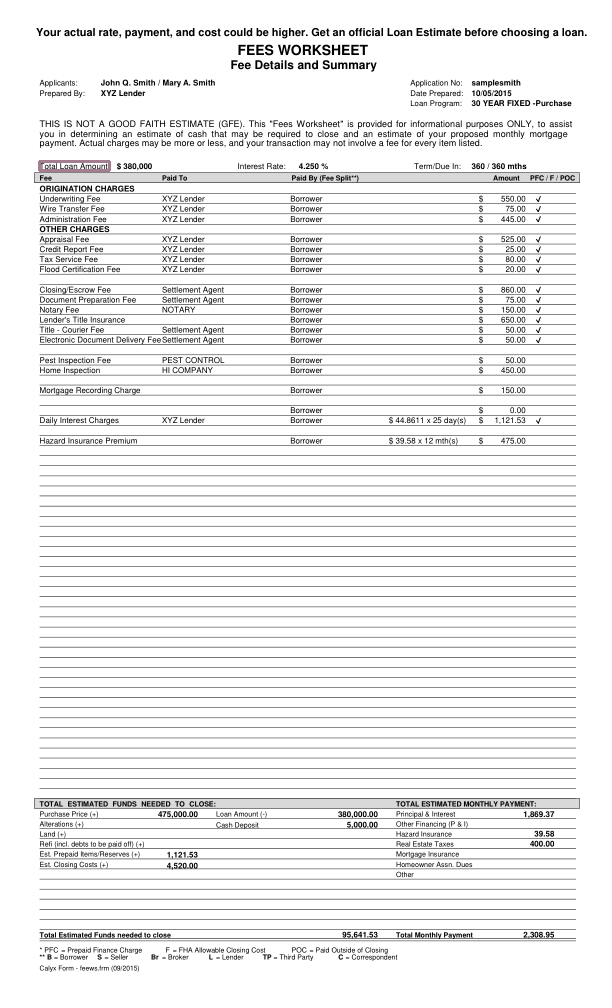

In [ ]:
# print image with specific text - 'Total Loan Amount'

import cv2 #to display image and bounding box
import numpy as np
from google.colab.patches import cv2_imshow #to display image
from PIL import Image #to convert pdf to image object and viceversa

#1. convert pdf to imageobject
#create a np array to store the pixel byte data
pix = sheet[0].get_pixmap()
img = np.array(Image.frombytes('RGB',(pix.width, pix.height),pix.samples))

#2. convert to BGR format used by opencv

img = cv2.cvtColor(img,cv2.COLOR_RGB2BGR)

#3. get the height to draw the bbpx
img_h = img.shape[0] #[0] accesses height

#4. extract the bounding box coords already done
#cell 10 has text = page1.get_text('words') #with bbox coords


#5. extract the key info text with regex
target = "Total Loan Amount:" #later on, i will use .lower() for case insensitive match

windowsize = 3
target_coord = []
for i in range(len(textlist) - windowsize + 1):
  textmatch = ' '.join(textlist[i:i+windowsize])
  if textmatch == target:
    target_coord = coordlist[i:i+windowsize] #only if there is a match, it will fetch the respective coords
    print(f'phrase found at {target_coord}')
    x0 = target_coord[0][0]
    y0 = target_coord[0][1]
    x1 = target_coord[2][2]
    y1 = target_coord[2][3]
    x0,y0,x1,y1 = map(int, [x0,y0,x1,y1])

#draw the rectangle

cv2.rectangle(img, (x0,y0),(x1,y1),(165,125,145), 2)

#convert back to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#display image
cv2_imshow(img_rgb)

Mistakes I made:
1. 'Total Loan Amount' DID have punctuation ':' which i didnt account for initially
2. Tried to match an entire phrase word by word -  I didnt know window slicing, which i know now.
3. coordinate building for a phrase -  x0,y0 is the x0,y0 of the first word (top left of word 1) x1,y1, is of the last word (bottom right of last word)
4. switched up pix.height and pix.width - the order is (pix.width, pix.height)